### Preparación de los datos:

In [4]:
import pandas as pd
import numpy as np

#### Train & Test

In [5]:
X_train = pd.read_csv('../data/training_sets/X_train.csv')
X_train.set_index('Unnamed: 0', inplace=True)
X_test = pd.read_csv('../data/training_sets/X_test.csv')
X_test.set_index('Unnamed: 0', inplace=True)
y_train = pd.read_csv('../data/training_sets/y_train.csv')
y_train.set_index('Unnamed: 0', inplace=True)
y_test = pd.read_csv('../data/training_sets/y_test.csv')
y_test.set_index('Unnamed: 0', inplace=True)

In [6]:
print(X_train.dtypes)
print(y_train.dtypes)

PR_interval        float64
P_duration         float64
P_amplitude        float64
R_amplitude        float64
S_depth            float64
T_amplitude        float64
T_wave_duration    float64
T_area             float64
T_asymmetry        float64
QRS_duration       float64
QT_interval        float64
HR                 float64
RR_mean            float64
RR_std             float64
dtype: object
Sex    int64
dtype: object


In [7]:
# Creación del modelo (KERAS)
import keras


model = keras.Sequential([
    keras.layers.Input(shape=(14,)),
    keras.layers.Dense(
        28,
        activation='relu',
        kernel_initializer="he_normal",
        kernel_regularizer=keras.regularizers.l2(0.001)
        ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(
        6,
        activation='relu',
        kernel_initializer="he_normal"
        ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(
        1,
        activation='sigmoid',
        kernel_initializer="glorot_uniform"
        )
])

In [8]:
# Compilación del modelo


model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0005,
        weight_decay=0.001
    ),
    loss=keras.losses.BinaryCrossentropy(), # Al ser un clasificador binario, se utiliza esta función de pérdida
    metrics=[
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name='precision'),     # 3. Precisión por sexo
        keras.metrics.Recall(name='recall'),        # 4. Sensibilidad por sexo
        keras.metrics.F1Score(name='f1_score'), 
        ]
)

In [9]:
# Entrenamiento
from sklearn.model_selection import StratifiedKFold


sk_fold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

dict_hist_train = {
    'Loss': [],
    'AUC': [],
    'Precision': [],
    'Recall': [],
    'F1Score': []
}

dict_hist_val = {
    'Loss': [],
    'AUC': [],
    'Precision': [],
    'Recall': [],
    'F1Score': []
}


for train_index, val_index in sk_fold.split(X_train, y_train):
    X, y = X_train.iloc[train_index], y_train.iloc[train_index]
    X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]
    
    print(model.output_shape)
    
    history = model.fit(x=X, y=y, batch_size=32, epochs=100, validation_data=(X_val, y_val))
    
    
    dict_hist_train['Loss'].append(history.history['loss'])
    dict_hist_train['AUC'].append(history.history['auc'])
    dict_hist_train['Precision'].append(history.history['precision'])
    dict_hist_train['Recall'].append(history.history['recall'])
    dict_hist_train['F1Score'].append(history.history['f1_score'])
    
    dict_hist_val['Loss'].append(history.history['val_loss'])
    dict_hist_val['AUC'].append(history.history['val_auc'])
    dict_hist_val['Precision'].append(history.history['val_precision'])
    dict_hist_val['Recall'].append(history.history['val_recall'])
    dict_hist_val['F1Score'].append(history.history['val_f1_score'])
    

print(dict_hist_train['Loss'])


(None, 1)
Epoch 1/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - auc: 0.5049 - f1_score: 0.7111 - loss: 0.8220 - precision: 0.5514 - recall: 0.6310 - val_auc: 0.5950 - val_f1_score: 0.7107 - val_loss: 0.7327 - val_precision: 0.6021 - val_recall: 0.6760
Epoch 2/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.5415 - f1_score: 0.7111 - loss: 0.7740 - precision: 0.5738 - recall: 0.6953 - val_auc: 0.6403 - val_f1_score: 0.7107 - val_loss: 0.7124 - val_precision: 0.6031 - val_recall: 0.8105
Epoch 3/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.5896 - f1_score: 0.7111 - loss: 0.7367 - precision: 0.5930 - recall: 0.7263 - val_auc: 0.6726 - val_f1_score: 0.7107 - val_loss: 0.6990 - val_precision: 0.6160 - val_recall: 0.8573
Epoch 4/100
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.6197 - f1_score: 0.7111 - loss: 0.7184 - precision: 0.6056 - recall: 0.7584 - val_auc: 0.6859 - val_f1_score: 0.7107 - val_loss: 0.6880 - val_precision: 0.6389 - val_recall: 0.7988
Epoch 5/100
194/19

In [ ]:
y_pred_model = model.predict(X_test).flatten()
y_true = np.array(y_test).flatten()
y_pred = (y_pred_model >= 0.4).astype(int)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [52]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_true, y_pred)

array([[721, 136],
       [496, 586]])

In [53]:
# Pruebas

from sklearn.metrics import classification_report


print(classification_report(
    y_true,
    y_pred
))

              precision    recall  f1-score   support

           0       0.59      0.84      0.70       857
           1       0.81      0.54      0.65      1082

    accuracy                           0.67      1939
   macro avg       0.70      0.69      0.67      1939
weighted avg       0.71      0.67      0.67      1939



In [38]:
precision_array_train = np.array(dict_hist_train['Precision']).flatten()
recall_array_train = np.array(dict_hist_train['Recall']).flatten()
auc_array_train = np.array(dict_hist_train['AUC']).flatten()

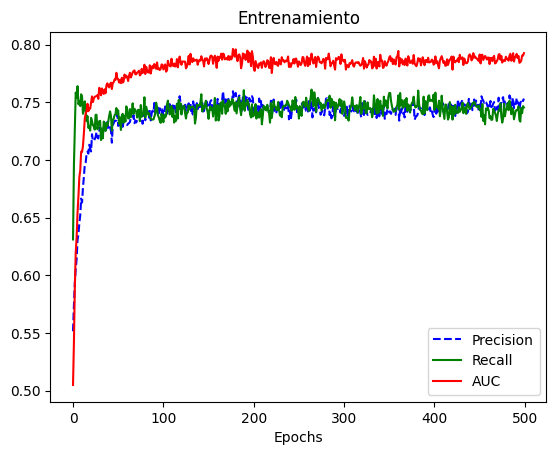

In [39]:
import matplotlib.pyplot as plt

plt.plot(precision_array_train, "b--", label="Precision") 
plt.plot(recall_array_train, "g-", label="Recall") 
plt.plot(auc_array_train, "r", label="AUC") 
plt.xlabel('Epochs') 
plt.title('Entrenamiento')
plt.legend() 
plt.show() 

In [40]:
precision_array_val = np.array(dict_hist_val['Precision']).flatten()
recall_array_val = np.array(dict_hist_val['Recall']).flatten()
auc_array_val = np.array(dict_hist_val['AUC']).flatten()

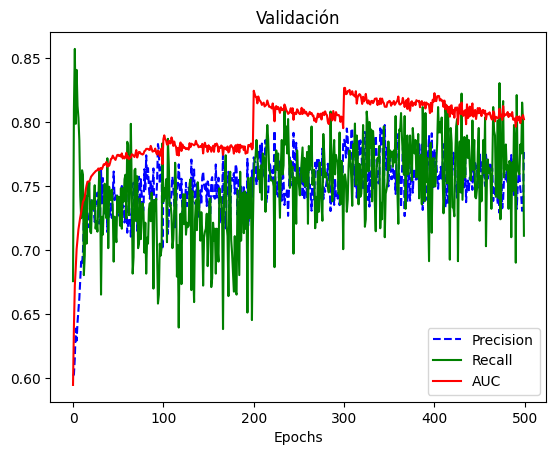

In [50]:

plt.plot(precision_array_val, "b--", label="Precision") 
plt.plot(recall_array_val, "g-", label="Recall") 
plt.plot(auc_array_val, "r", label="AUC") 
plt.title('Validación')
plt.xlabel('Epochs') 
plt.legend() 
plt.show() 

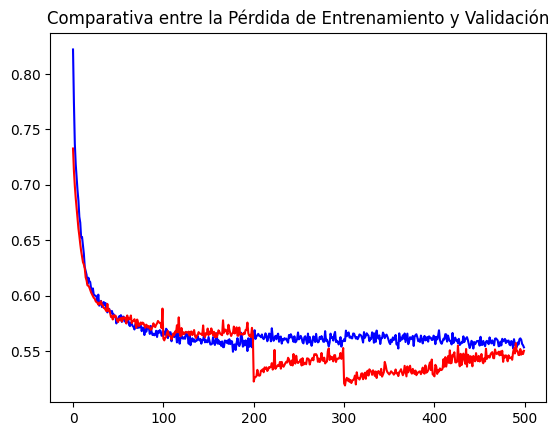

In [42]:
# Plotear

loss_train = np.array(dict_hist_train['Loss']).flatten()
loss_val = np.array(dict_hist_val['Loss']).flatten()


plt.plot(loss_train, c="blue", label="Entrenamietno")
plt.plot(loss_val, c="red", label="Validación")
plt.title("Comparativa entre la Pérdida de Entrenamiento y Validación")
plt.show()

In [43]:
# Save model

model.save('../models/model.keras')